In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Assignment 1: Wrangling and EDA

**Q1.**

In [8]:
df_airbnb = pd.read_csv('../data/airbnb_NYC.csv', encoding="latin1")

# Q1.1: Remove "$" and ","
df_airbnb['price_clean'] = pd.to_numeric(
    df_airbnb['Price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
)
print("Q1.1 Missing Prices:", df_airbnb['price_clean'].isna().sum())

# Q1.2: Data appears to be disproportionately missing when bodily force was used.
df_police = pd.read_csv('../data/mn_police_use_of_force.csv')
print("Q1.2 Prop Missing:", df_police['subject_injury'].isna().mean())
print(pd.crosstab(df_police['subject_injury'].fillna('NaN'), df_police['force_type']))
df_police['subject_injury_clean'] = df_police['subject_injury'].fillna('Missing')

# Q1.3
df_metabric = pd.read_csv('../data/metabric.csv')
df_metabric['survival_dummy'] = df_metabric['Overall Survival Status'].map({'Living': 1, 'Deceased': 0})

# Q1.4: If missing values are correlated with negative experiences, this artificially inflates ratings.
missing_reviews = df_airbnb['Review Scores Rating'].isna().sum()
median_rating = df_airbnb['Review Scores Rating'].median()
df_airbnb['review_imputed'] = df_airbnb['Review Scores Rating'].fillna(median_rating)
print("Q1.4 Missing Reviews:", missing_reviews)

Q1.1 Missing Prices: 0
Q1.2 Prop Missing: 0.7619342359767892
force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
NaN                 2          7051               1421        0   
No                  0          1093                131        2   
Yes                 2          1286                 41        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury                                                      
NaN                            27                 74           87   
No                             33                 34            0   
Yes                            44                 40            0   

force_type      Less Lethal Projectile  Maximal Restraint Technique  \
subject_injury                                                        
NaN                                  0                          170   
No                                   1      

**Q2.**

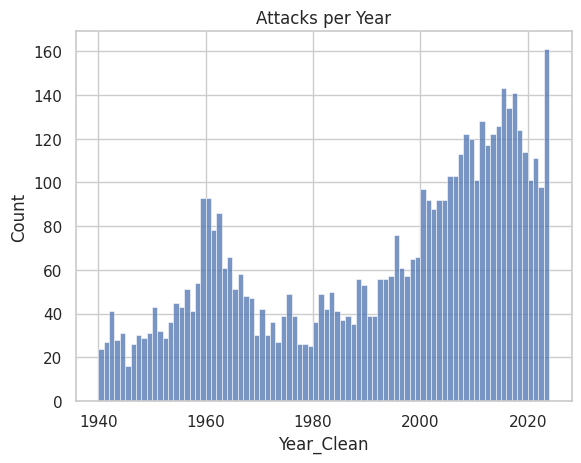

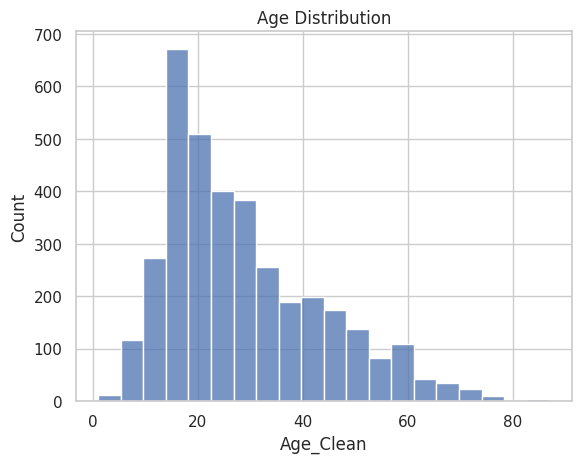

Q2.6 Unprovoked Prop: 0.7450343084145901
Fatal_Clean         N   Unknown         Y
Type_Clean                               
Provoked     0.971319  0.003824  0.024857
Unknown      0.857143  0.003375  0.139483
Unprovoked   0.830829  0.000969  0.168202


In [9]:
# Q2.1
df_shark = pd.read_excel("../data/GSAF5.xls")

# Q2.2
df_shark = df_shark.dropna(axis=1, how='all')

# Q2.3: An observation is an event that involves a shark and a human/ship. Some of the rows in the dataset contain invalid reports/scavenging which aren't attacks.

# Q2.4: Attacks are increasing over time.
df_shark['Year_Clean'] = pd.to_numeric(df_shark['Year'], errors='coerce')
df_recent = df_shark[df_shark['Year_Clean'] >= 1940].copy()
plt.figure()
sns.histplot(data=df_recent, x='Year_Clean', bins=range(1940, 2025))
plt.title("Attacks per Year")
plt.show()

# Q2.5
df_recent['Age_Clean'] = pd.to_numeric(df_recent['Age'], errors='coerce')
plt.figure()
sns.histplot(data=df_recent, x='Age_Clean', bins=20)
plt.title("Age Distribution")
plt.show()

# Q2.6
def clean_type(val):
    val = str(val).lower()
    if "unprovoked" in val: return "Unprovoked"
    if "provoked" in val: return "Provoked"
    return "Unknown"
df_recent['Type_Clean'] = df_recent['Type'].apply(clean_type)
print("Q2.6 Unprovoked Prop:", (df_recent['Type_Clean'] == 'Unprovoked').mean())

# Q2.7
def clean_fatal(val):
    val = str(val).upper()
    if 'Y' in val: return 'Y'
    if 'N' in val: return 'N'
    return "Unknown"
df_recent['Fatal_Clean'] = df_recent['Fatal Y/N'].apply(clean_fatal)
print(pd.crosstab(df_recent['Type_Clean'], df_recent['Fatal_Clean'], normalize='index'))

# Q2.8: Attacks are more likely to be fatal when unprovoked, possibly due to unprovoked attacks being attributed to a shark's predatory behavior.

**Q3.**
1.  The paper is about tidy data, standardizing data cleaning, and making data analysis more efficient.

2.  The standard is meant to ensure compatibility across tools and reduce time spent on data wrangling.

3.
> "Like families, tidy datasets are all alike but every messy dataset is messy in its own way"

Tidy datasets share a singular structure, but messy datasets are uniquely chaotic.
> "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."

It's a simple task to identify the observations and variables but to understand those observations and variables is a much more difficult task.

4.
- Value -- Measure (cell).
- Variable -- Attribute across units (column).
- Observation -- All measures for a unit (row).

5. Tidy data is defined as variables being columns, observations being rows, and observational unit types being tables.

6.
- Problems -- Headers as values, multiple variables in one column, variables in rows/columns, mixed units, split units.
- Headers -- (`<$10k`) are values of the "Income" variable, not variable names.
- Melting -- Stacking columns into rows (converting Wide Data to Long Data).
7.  Table 11 has the "Day" variable across headers (messy) while Table 12 has them altogether in the Date column (tidy/molten).

**Q4.**

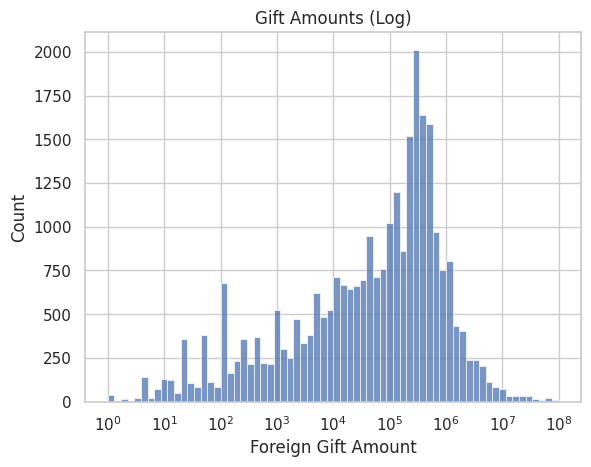

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                8874

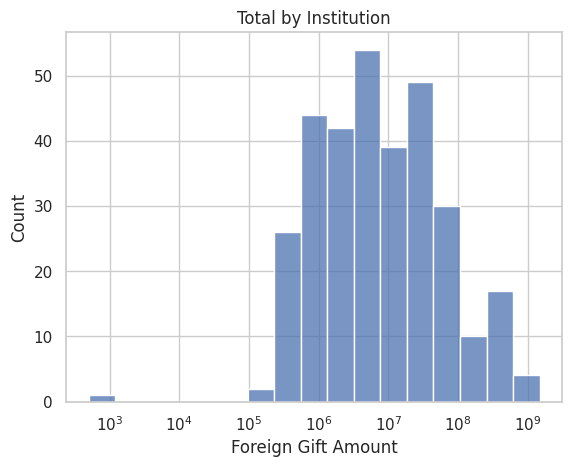

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


In [10]:
# Q4.1
df_gifts = pd.read_csv('../data/ForeignGifts_edu.csv')

# Q4.2
plt.figure()
sns.histplot(df_gifts['Foreign Gift Amount'], log_scale=True)
plt.title("Gift Amounts (Log)")
plt.show()
print(df_gifts['Foreign Gift Amount'].describe())

# Q4.3
print(df_gifts['Gift Type'].value_counts(normalize=True))

# Q4.4
print(df_gifts['Country of Giftor'].value_counts().head(15))
print(df_gifts.groupby('Country of Giftor')['Foreign Gift Amount'].sum().nlargest(15))

# Q4.5
inst_sums = df_gifts.groupby('Institution Name')['Foreign Gift Amount'].sum().nlargest(15)
print(inst_sums)
plt.figure()
sns.histplot(df_gifts.groupby('Institution Name')['Foreign Gift Amount'].sum(), log_scale=True)
plt.title("Total by Institution")
plt.show()

# Q4.6
print(df_gifts.groupby('Giftor Name')['Foreign Gift Amount'].sum().nlargest(15))

**Q5.**

(3798, 63)
   index  unitid                            chronname        city    state  \
0      0  100654               Alabama A&M University      Normal  Alabama   
1      1  100663  University of Alabama at Birmingham  Birmingham  Alabama   
2      2  100690                   Amridge University  Montgomery  Alabama   
3      3  100706  University of Alabama at Huntsville  Huntsville  Alabama   
4      4  100724             Alabama State University  Montgomery  Alabama   

    level                 control  \
0  4-year                  Public   
1  4-year                  Public   
2  4-year  Private not-for-profit   
3  4-year                  Public   
4  4-year                  Public   

                                               basic hbcu flagship  ...  \
0  Masters Colleges and Universities--larger prog...    X      NaN  ...   
1  Research Universities--very high research acti...  NaN      NaN  ...   
2            Baccalaureate Colleges--Arts & Sciences  NaN      NaN  ... 

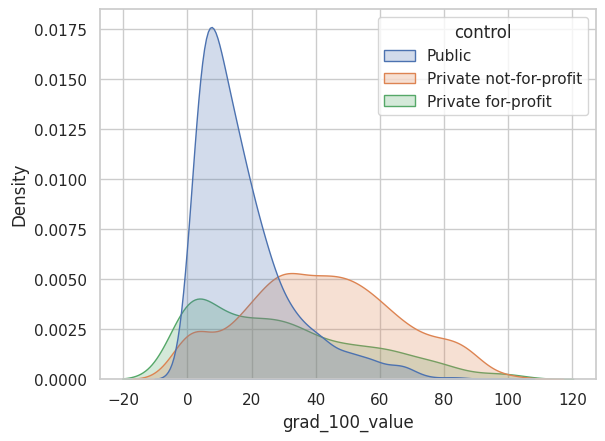

                         count       mean        std  min    25%   50%    75%  \
control                                                                         
Private for-profit       779.0  29.108858  25.601687  0.0   6.95  24.7  46.75   
Private not-for-profit  1189.0  41.660976  23.551231  0.0  25.00  41.0  58.30   
Public                  1499.0  17.430887  14.729443  0.0   6.90  13.2  23.25   

                          max  
control                        
Private for-profit      100.0  
Private not-for-profit  100.0  
Public                   97.8  


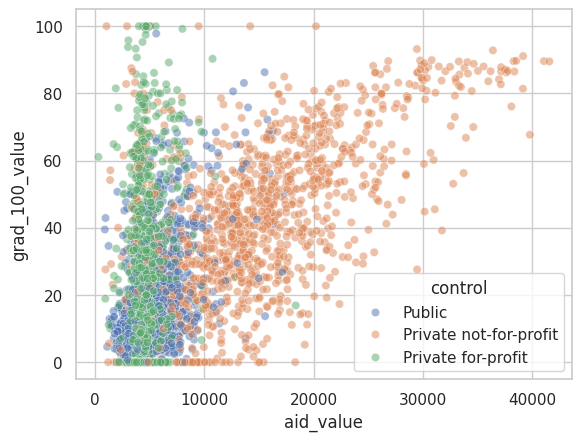

Overall Corr: 0.5758792845936064
control                          
Private for-profit      aid_value    0.188363
Private not-for-profit  aid_value    0.601591
Public                  aid_value    0.482481
Name: grad_100_value, dtype: float64


In [11]:
# Q5.1
df_college = pd.read_csv('../data/college_completion.csv')

# Q5.2
print(df_college.shape)
print(df_college.head())

# Q5.3: Private for-profit colleges are evenly split on being 2-year or 4-year programs. Private not-for-profit colleges are mostly 4-year programs. Public colleges are more likely to be 2-year programs.
print(pd.crosstab(df_college['control'], df_college['level']))

# Q5.4
plt.figure()
sns.kdeplot(data=df_college, x='grad_100_value', hue='control', fill=True)
plt.show()
print(df_college.groupby('control')['grad_100_value'].describe())

# Q5.5: Private not-for-profit institutions appears to have aid vary positively with graduation rates.
plt.figure()
sns.scatterplot(data=df_college, x='aid_value', y='grad_100_value', hue='control', alpha=0.5)
plt.show()

numeric = ['aid_value', 'grad_100_value']
print("Overall Corr:", df_college[numeric].corr().iloc[0, 1])
print(df_college.groupby('control')[numeric].corr().iloc[0::2, 1])

**Q6. (note: I use LaTeX daily for notes in a Marimo notebook, so I found this to be the easiest medium for my answers)**
1.  **Mean:** $m(a+bX) = \frac{1}{N}\sum(a+bx_i) = a + b \frac{1}{N}\sum x_i = a + b m(X)$.
2.  **Cov(X,X):** $\frac{1}{N}\sum(x_i-m(X))^2 = s^2$.
3.  **Cov(X, a+bY):** $\text{cov}(X, a+bY) = b \cdot \text{cov}(X,Y)$ (constants vanish, scale factors out).
4.  **Cov(a+bX, a+bY):** $b \cdot \text{cov}(a+bX, Y) = b \cdot b \cdot \text{cov}(X,Y) = b^2 \text{cov}(X,Y)$.
5.  **Median/IQR:** Yes for both (if $b>0$). Linear transformations preserve order (Median) and scale distances (IQR).
6.  **Non-linear:** $X=\{1,2,3\}$. $m(X)=2, m(X)^2=4$. $X^2=\{1,4,9\}, m(X^2)=4.66 \neq 4$.

**Q7.**

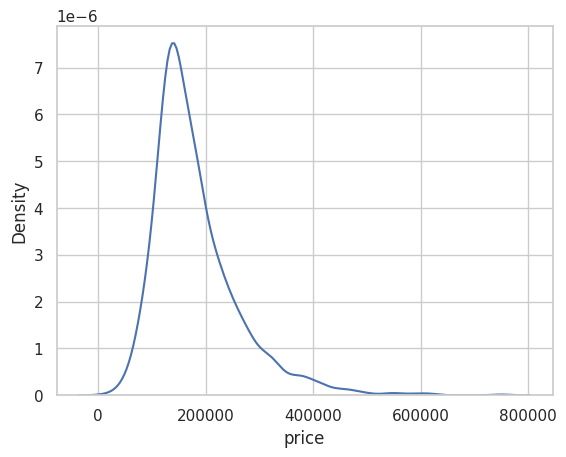

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: price, dtype: float64


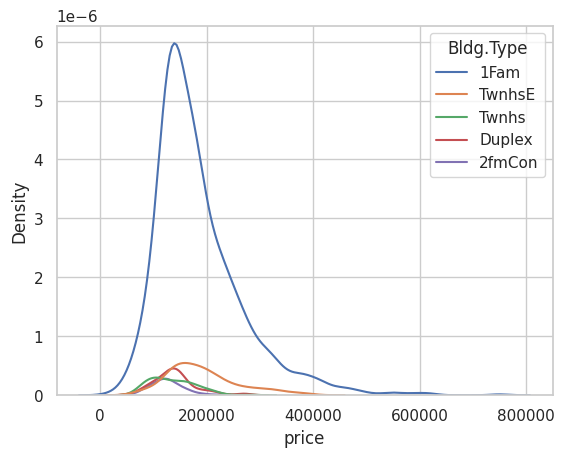

            count           mean           std      min       25%       50%  \
Bldg.Type                                                                     
TwnhsE      233.0  192311.914163  66191.738021  71000.0  145000.0  180000.0   
1Fam       2425.0  184812.041237  82821.802329  12789.0  130000.0  165000.0   
Duplex      109.0  139808.935780  39498.973534  61500.0  118858.0  136905.0   
Twnhs       101.0  135934.059406  41938.931130  73000.0  100500.0  130000.0   
2fmCon       62.0  125581.709677  31089.239840  55000.0  106562.5  122250.0   

                75%       max  
Bldg.Type                      
TwnhsE     222000.0  392500.0  
1Fam       220000.0  755000.0  
Duplex     153337.0  269500.0  
Twnhs      170000.0  280750.0  
2fmCon     140000.0  228950.0  


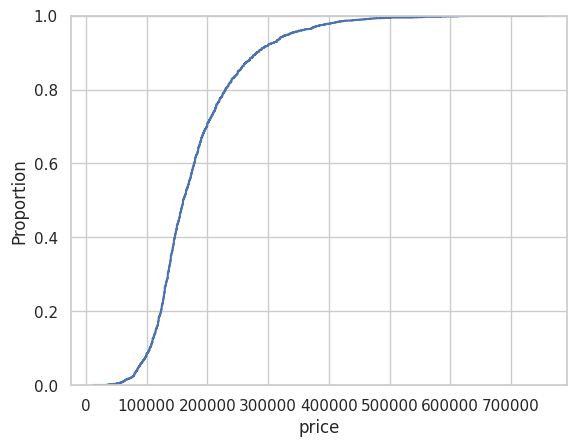

0.00     12789.0
0.25    129500.0
0.50    160000.0
0.75    213500.0
1.00    755000.0
Name: price, dtype: float64


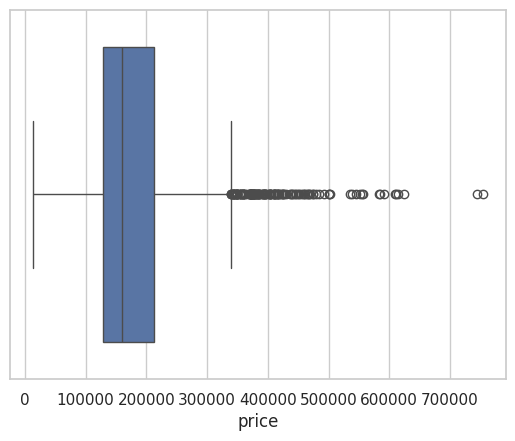

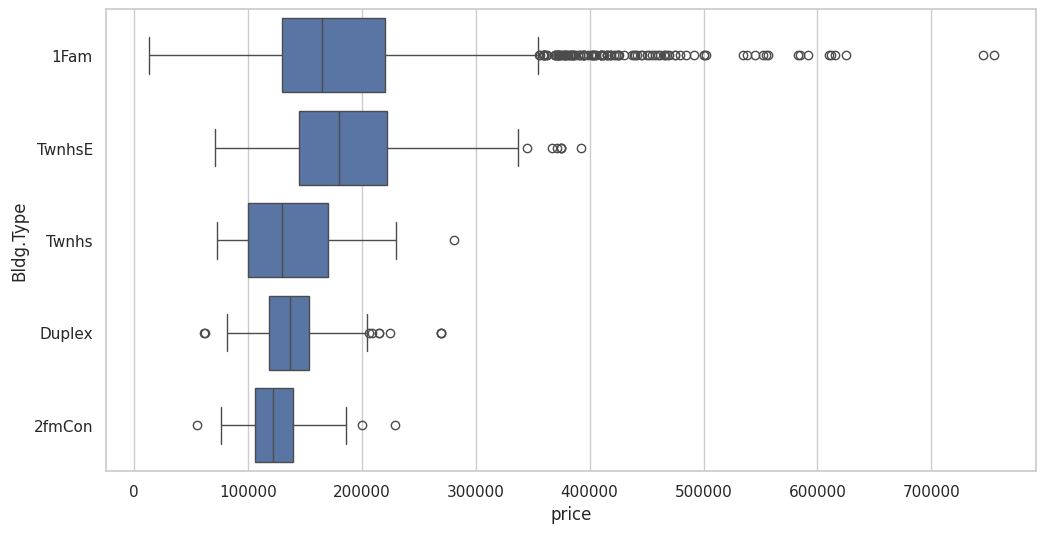

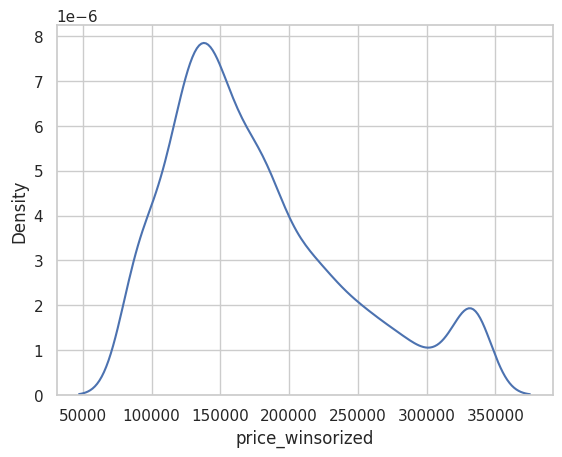

count      2930.000000
mean     177632.528669
std       66195.453960
min       87500.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      335000.000000
Name: price_winsorized, dtype: float64


In [12]:
# Q7.1
df_ames = pd.read_csv('../data/ames_prices.csv')

# Q7.2: Townhouses are the most expensive, on average. Single-family homes have the highest variance in transaction prices.
plt.figure()
sns.kdeplot(df_ames['price'])
plt.show()
print(df_ames['price'].describe())
plt.figure()
sns.kdeplot(data=df_ames, x='price', hue='Bldg.Type')
plt.show()
print(df_ames.groupby('Bldg.Type')['price'].describe().sort_values('mean', ascending=False))

# Q7.3
plt.figure()
sns.ecdfplot(df_ames['price'])
plt.show()
print(df_ames['price'].quantile([0, 0.25, 0.5, 0.75, 1]))

# Q7.4: Yes, there are lots of outliers. I don't see many patterns not already mentioned in my response to Q7.2. There are more outliers in Single-family houses than any other building type but that is simply due to the fact that they are overrepresented in our dataset.
plt.figure()
sns.boxplot(x=df_ames['price'])
plt.show()
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_ames['price'], y=df_ames['Bldg.Type'])
plt.show()

# Q7.5
Q1 = df_ames['price'].quantile(0.25)
Q3 = df_ames['price'].quantile(0.75)
IQR = Q3 - Q1
df_ames['is_outlier'] = ((df_ames['price'] < (Q1 - 1.5 * IQR)) | (df_ames['price'] > (Q3 + 1.5 * IQR))).astype(int)

# Q7.6: The results change by letting us see a second minor peak around 325k that was not visible in the plot from Q7.2.
p05 = df_ames['price'].quantile(0.05)
p95 = df_ames['price'].quantile(0.95)
df_ames['price_winsorized'] = df_ames['price'].clip(p05, p95)
plt.figure()
sns.kdeplot(df_ames['price_winsorized'])
plt.show()
print(df_ames['price_winsorized'].describe())